## Installing uv

To start, you'll want to have uv installed:

https://docs.astral.sh/uv/getting-started/installation/


**Next, run this in the terminal, from the parent directory:**

    uv sync


Now you will have the kernel used to run this notebook

---

## Running the Required Servers

You need to run **three servers**, each in its own terminal:

- `central_server.py`
- `AS_server.py`
- `Ceos_server.py`

### 1. Activate the Virtual Environment

`uv` should have created a `.venv` directory for you.

**On macOS / Linux:**

    source .venv/bin/activate

**On Windows (likely):**

    source .venv/Scripts/activate

You should now see the environment activated.

---

### 2. Start the Servers

**Terminal 1 — Central Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.protocols.central_server

**Terminal 2 — Atom Resolution Simulation Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.AS_server

**Terminal 3 — CEOS Twin Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.Ceos_server

---

You're now ready to run this notebook! 🚀

In [2]:
import sys
import ast
import numpy as np
sys.path.insert(0, '../')
from asyncroscopy.clients.notebook_client import NotebookClient
from asyncroscopy.utils import parula_color_map
import matplotlib.pyplot as plt
from skimage.feature import blob_log
from scipy.ndimage import gaussian_filter
import pyTEMlib
from pyTEMlib import probe_tools as pt

%matplotlib ipympl

### Connections:

In [3]:
# Connect the Client to the central (async) server
tem = NotebookClient.connect(host='localhost', port=9000)

# Tell the central server address of all connected instruments
routing_table= {"AS": ("localhost", 9001),
                "Gatan": ("localhost", 9002),
                "Ceos": ("localhost", 9003),
                "Preacquired_AS": ("localhost", 9004)}
tem.send_command('Central',"set_routing_table", routing_table)

# ConnectionResetError: [Errno 54] Connection reset by peer 
# in terminal, type:
# lsof -i :9000
# then kill PIDs on that port


Connecting to central server localhost:9000...
Connected to central server.


'[Central] Routing table updated'

In [5]:
# connect to the microscope hardware computer and initialize microscope
tem.send_command('AS',command='connect_AS',args={'host':'localhost','port':9095})
tem.send_command(destination = 'Ceos', command = 'getInfo', args = {})

KeyboardInterrupt: 

### Help commands:

In [7]:
# Now that we're routed to all instruments,
# let's take an inventory of commands available on each instrument
cmds = tem.send_command('AS', 'discover_commands')
print(cmds)

["blank_beam", "connect_AS", "connectionLost", "connectionMade", "dataReceived", "disconnect", "discover_commands", "get_atom_count", "get_dose_map", "get_help", "get_scanned_image", "get_stage", "get_status", "lengthLimitExceeded", "load_sample", "logPrefix", "makeConnection", "pauseProducing", "place_beam", "reset_sample", "resumeProducing", "sendString", "set_beam_current", "set_fov", "stopProducing", "stringReceived", "unblank_beam"]


### Getting the aberrations:

Do this at 225 kx

In [ ]:
aberrations = tem.send_command(destination = 'Ceos', command = 'acquireTableau', args = {'tabType':"Fast", 'angle':18})
pt.print_aberrations(aberrations)

### Calibrate the probe fluence:

In [ ]:
tem.send_command('AS', 'calibrate_screen_current')

# then set current to test
beam_current = 100 # pA
tem.send_command('AS', 'set_beam_current', {'current':beam_current}) # pA

### Get an image:

Real image

'Current atom count: 3600'

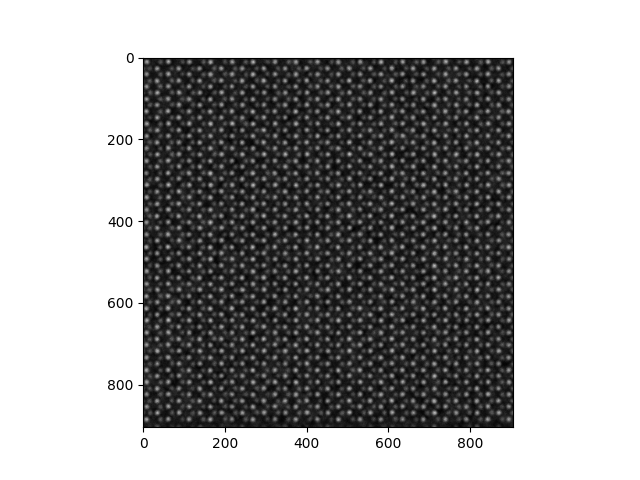

In [10]:
image_args = {'scanning_detector':'HAADF',
                'size':512,
                'dwell_time':10e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.figure()
plt.imshow(img, cmap="gray")
tem.send_command('AS', 'get_atom_count', {})

### The Experiment

We need to know electrons/area/time

electrons/area/time = current / (e * area)

we directly set and measure the current

we get area by measuring probe size!  How?  Through the aberrations!


In [ ]:
current_vals = [10, 30, 50, 80, 100, 200, 500, 1000, 5000, 10000]
probes = []
ab_list = []
for current in current_vals: # pA

    # set current
    tem.send_command('AS', 'set_beam_current', {'current':current}) # pA

    # focus again
    tem.send_command('AS','tune_C1A1')

    # get probe size
    aberrations = tem.send_command(destination = 'Ceos', command = 'acquireTableau', args = {'tabType':"Fast", 'angle':18})
    ab_list.append(aberrations)
    probe, A_k, chi  = pt.aberrations(aberrations, 128, 128, verbose= True)
    probes.append(probe)

    break

profiles = [np.sum(p, axis=0) for p in probes]
